In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def analyze_euler_stability(k, h_values, x_end):
    # Initial conditions
    y0 = 1.0
    v0 = 0.0
    
    # System matrix A where du/dt = A * u
    # u = [y, v]^T -> dy/dt = v, dv/dt = -ky
    A = np.array([[0, 1],[-k, 0]])
    
    plt.figure(figsize=(12, 8))
    
    for h in h_values:
        # Construct the Euler coefficient matrix: M = I + h*A
        I = np.eye(2)
        M = I + h * A
        
        # Compute eigenvalues
        eigenvalues = np.linalg.eigvals(M)
        max_magnitude = np.max(np.abs(eigenvalues))
        
        # Output stability status
        print(f"Step Size (h): {h}")
        if max_magnitude <= 1.0:
            print("Solution is Stable")
        else:
            print("Solution may not be Entirely Stable ;)")
        print(f"Max Eigenvalue Magnitude: {max_magnitude:.4f}\n")
        
        # Simulation
        steps = int(x_end / h)
        x_vals = np.linspace(0, x_end, steps + 1)
        u = np.zeros((steps + 1, 2))
        u[0] = [y0, v0]
        
        for i in range(steps):
            u[i+1] = M @ u[i]
            
        plt.plot(x_vals, u[:, 0], label=f'h = {h}')
    
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Euler Method Simulation (k={k})")
    plt.xlabel("x")
    plt.ylabel("y(x)")
    plt.legend()
    plt.grid(True)
    plt.show()

Step Size (h): 0.01
Solution may not be Entirely Stable ;)
Max Eigenvalue Magnitude: 1.0000

Step Size (h): 0.05
Solution may not be Entirely Stable ;)
Max Eigenvalue Magnitude: 1.0012

Step Size (h): 0.1
Solution may not be Entirely Stable ;)
Max Eigenvalue Magnitude: 1.0050

Step Size (h): 0.2
Solution may not be Entirely Stable ;)
Max Eigenvalue Magnitude: 1.0198



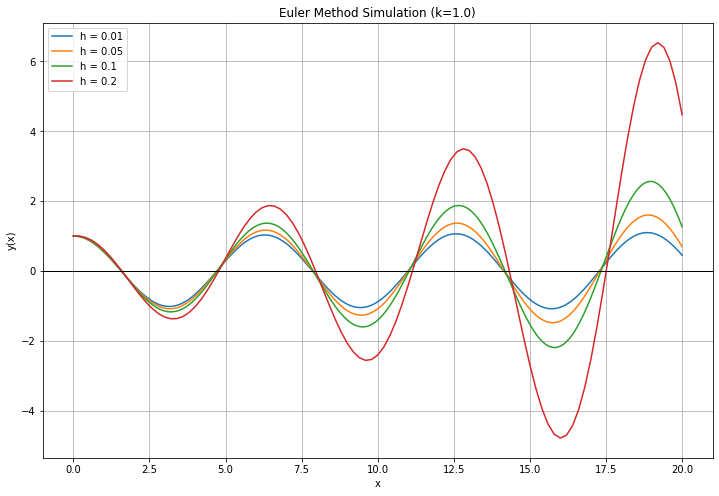

In [9]:
# Execution
k_constant = 1.0
test_h = [0.01, 0.05, 0.1, 0.2]
analyze_euler_stability(k_constant, test_h, x_end=20)